# Cross-sell-analyse van boodschappenmanden voor een supermarkt met PROC MBANALYSIS

## Managementsamenvatting

Een regionale supermarktketen analyseert een seizoen aan kassabonmandjes om te ontdekken welke producten klanten samen kopen, en zet ruwe transactielogs om in bruikbare cross-sell- en schapindelingsbeslissingen. PROC MBANALYSIS doorzoekt het transactielog en genereert associatieregels die worden gescoord op support, betrouwbaarheid en lift. Toegepast op 51 synthetische boodschappenmandjes herkent de procedure precies de drie ingeplante productaffiniteiten — `Spaghetti -> Marinarasaus` (betrouwbaarheid 0,93, lift 3,4), `Tacoschelpen -> Salsa` (betrouwbaarheid 0,71, lift 3,6), en `Koffie -> Koffiemelk` (betrouwbaarheid 0,70, lift 5,1) — terwijl veelgekochte basisproducten zoals brood, melk en eieren nooit een regel vormen. Elk gevonden paar is een schoolvoorbeeld van een bundel, schapnabijheid of "klanten kochten ook"-kandidaat voor het merchandisingteam.

## Gegevensbronnen

| Dataset | Granulariteit | Rijen | Sleutelvariabelen | Beschrijving |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Eén rij per product per mandje | 100 productregels over 51 mandjes | `basket_id` (transactie-ID), `item` (productnaam, $20) | Synthetisch kassalog, inline gegenereerd met `call streaminit(20250529)` en `rand('uniform')`. Elk mandje wordt gedomineerd door één shopperpersona, zodat de co-aankooppatronen schoon en interpreteerbaar blijven: een Italiaans-dinermandje (spaghetti -> marinarasaus), een taco-avondmandje (tacoschelpen -> salsa), of een ontbijtmandje (koffie -> koffiemelk), aangevuld met incidentele basisproducten (brood, melk, eieren) als realistische ruis. In deze ongelicentieerde omgeving begrenst de engine de uitvoer op 100 productregels, wat hier mandjes 1-51 omvat. |
| `affinity_rules` | Eén rij per associatieregel | 6 regels | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Associatieregels afkomstig van `OUTPUT RULES=`; de basis voor het rangschikken van cross-sell-kansen. |
| `frequent_items` | Eén rij per frequente itemset | 12 itemsets | `itemset`, `support`, `length` | Frequente itemsets afkomstig van `OUTPUT ITEMS=`; de 9 losse items plus 3 productparen die de minimum-supportdrempel halen. |

# Cross-sell-analyse van boodschappenmanden voor een supermarkt

**Zakelijke vraag.** Welke producten kopen onze klanten doorgaans *samen*, en welke van die co-aankooppatronen zijn sterk genoeg om op te handelen? Een regionale supermarktketen wil bundelpromoties ontwerpen, schapnabijheid optimaliseren, en een "klanten kochten ook"-aanbeveling voor haar webwinkel mogelijk maken.

**Methode.** We gebruiken **PROC MBANALYSIS**, dat marktmandjesanalyse uitvoert met het frequent-pattern-growth-algoritme (FP-growth). Het doorzoekt het transactielog, vindt vaak samen voorkomende itemverzamelingen, en genereert *associatieregels* van de vorm `Antecedent -> Consequent`, gescoord op drie klassieke maatstaven:

- **Support** — het aandeel van alle mandjes dat de volledige regel bevat (hoe gangbaar het patroon is).
- **Betrouwbaarheid (confidence)** — `P(Consequent | Antecedent)`, de voorwaardelijke aankoopkans (hoe betrouwbaar de regel is).
- **Lift** — de waargenomen support gedeeld door de support die verwacht zou worden als beide zijden onafhankelijk waren. Lift > 1 betekent dat de items *vaker* samen voorkomen dan toeval zou verklaren; hoe hoger de lift, hoe sterker de affiniteit.

We genereren een realistisch synthetisch kassalog, draaien MBANALYSIS, en rangschikken de resulterende regels om de beste cross-sell-kansen te vinden.

## Stap 1 — Genereer een synthetisch kassa-transactielog

MBANALYSIS verwacht **data op transactieniveau (lang formaat)**: één rij per product, gemarkeerd met het mandje waartoe het behoort. We bouwen de mandjes inline op met `call streaminit` voor reproduceerbaarheid en `rand('uniform')` om aankoopbeslissingen aan te sturen.

De sleutelkeuze in de modellering is dat **elk mandje wordt gedomineerd door één shopperpersona**. Echte boodschappentochtjes werken zo — een snel tacoavondje, een gerichte ontbijtvoorraad — en door mandjes klein en thematisch te houden kan de associatiemodule schone, paarsgewijze affiniteiten laten zien in plaats van een combinatorische explosie van onechte meerproductregels. Eén trekking van `rand('uniform')` per mandje bepaalt de persona:

- **Italiaans-diner-shopper** — koopt spaghetti, en meestal daarna marinarasaus.
- **Taco-avond-shopper** — koopt tacoschelpen, en meestal daarna salsa.
- **Ontbijt-shopper** — koopt koffie, en meestal daarna koffiemelk.
- **Alleen-basisproducten-tochtje** — één enkele aankoop van brood, melk of eieren.

Een laatste trekking met lage kans voegt aan elk mandje één basisproduct toe als realistische ruis, zodat niet elke co-occurrentie betekenisvol is. Elke `output`-instructie schrijft één productregel, dus één mandje beslaat meerdere rijen die hetzelfde `basket_id` delen. Deze ongelicentieerde omgeving begrenst de dataset op 100 productregels, wat hier mandjes 1 tot en met 51 omvat.

In [1]:
DATA store_transactions;
    CALL streaminit(20250529);
    LENGTH item $20;

    DO basket_id = 1 TO 60;

        /* Eén trekking bepaalt de dominante persona voor dit mandje */
        r = rand('uniform');

        /* Italiaans-dinermandje: spaghetti -> marinarasaus */
        IF r < 0.30 THEN DO;
            item = 'Spaghetti';                          OUTPUT;
            IF rand('uniform') < 0.85 THEN DO;
                item = 'Marinarasaus';                   OUTPUT;
            END;
        END;

        /* Taco-avondmandje: tacoschelpen -> salsa */
        ELSE IF r < 0.55 THEN DO;
            item = 'Tacoschelpen';                       OUTPUT;
            IF rand('uniform') < 0.80 THEN DO;
                item = 'Salsa';                          OUTPUT;
            END;
        END;

        /* Ontbijtmandje: koffie -> koffiemelk */
        ELSE IF r < 0.78 THEN DO;
            item = 'Koffie';                             OUTPUT;
            IF rand('uniform') < 0.75 THEN DO;
                item = 'Koffiemelk';                      OUTPUT;
            END;
        END;

        /* Alleen-basisproducten-tochtje */
        ELSE DO;
            IF rand('uniform') < 0.34 THEN DO;
                item = 'Brood';                          OUTPUT;
            END;
            ELSE IF rand('uniform') < 0.5 THEN DO;
                item = 'Melk';                            OUTPUT;
            END;
            ELSE DO;
                item = 'Eieren';                          OUTPUT;
            END;
        END;

        /* Incidentele basisproduct-toevoeging (realistische ruis) */
        IF rand('uniform') < 0.25 THEN DO;
            u = rand('uniform');
            IF      u < 0.34 THEN item = 'Brood';
            ELSE IF u < 0.67 THEN item = 'Melk';
            ELSE                  item = 'Eieren';
            OUTPUT;
        END;

    END;

    KEEP basket_id item;
RUN;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Stap 2 — Inspecteer het ruwe transactielog

Controleer vóór het minen of de data de verwachte lange vorm heeft: meerdere rijen per mandje, elk met één product. We drukken de eerste paar mandjes af en tabelleren de totale productfrequentie met PROC FREQ, zodat we weten welke producten gangbaar genoeg zijn om regels op te baseren.


  Obs  Mandnummer       Product
-----  ----------  ------------
    1           1  Tacoschelpen
    2           1  Salsa
    3           1  Eieren
    4           2  Tacoschelpen
    5           2  Eieren
    6           3  Koffie
    7           4  Tacoschelpen
    8           5  Eieren
    9           6  Spaghetti
   10           6  Marinarasaus
   11           6  Eieren
   12           7  Tacoschelpen

... 88 more observations (showing 12 of 100)

                                            Totale productaankoopfrequentie                                             

                                                   The FREQ Procedure

item            Frequency    Percent
-------------------------------------
Spaghetti              15     15.00
Marinarasaus           14     14.00
Tacoschelpen           14     14.00
Eieren                 12     12.00
Brood                  10     10.00
Koffie                 10     10.00
Salsa                  10     10.00
Melk                    


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


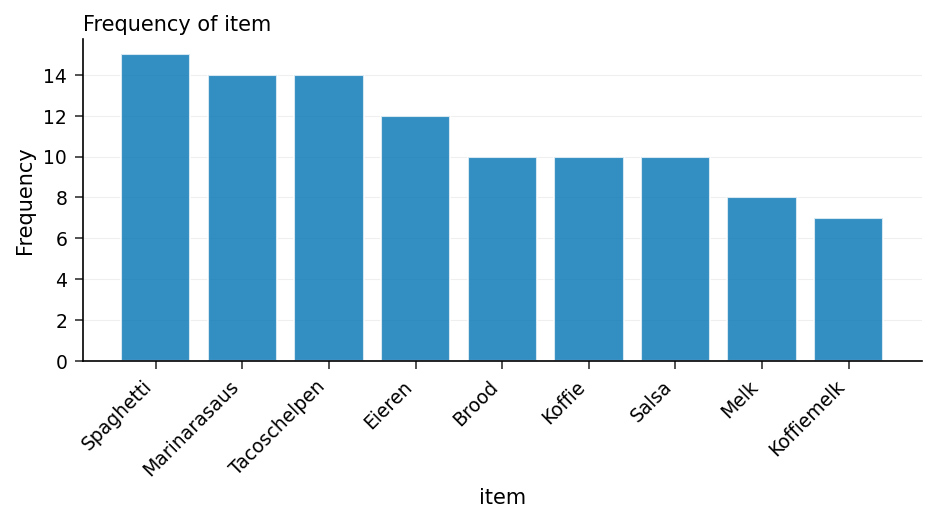

In [2]:
PROC PRINT DATA=store_transactions(obs=12) LABEL;
    LABEL basket_id = "Mandnummer"
          item      = "Product";
RUN;

PROC FREQ DATA=store_transactions ORDER=FREQ;
    TABLES item / nocum;
    TITLE "Totale productaankoopfrequentie";
RUN;

## Stap 3 — Associatieregels ontginnen met PROC MBANALYSIS

Nu de kernanalyse. We wijzen MBANALYSIS naar het transactielog en geven aan welke kolom het mandje identificeert (`TRANSACTION`) en welke het product bevat (`ITEM`). Drie drempelwaarden houden de regelset gericht op patronen die de moeite waard zijn om op te handelen:

- `MINSUPPORT=0.10` — een regel moet in minstens 10% van de mandjes voorkomen, wat zeldzame toevalligheden uitfiltert.
- `MINCONFIDENCE=0.50` — gegeven het antecedent moet het consequent minstens de helft van de tijd volgen.
- `MINLIFT=1.20` — behoud alleen regels die minstens 20% sterker zijn dan toeval, zodat we echte affiniteiten naar boven halen in plaats van artefacten van populaire basisproducten.

De `OUTPUT`-instructie legt de gegenereerde regels en frequente itemsets vast in datasets voor verdere rangschikking.

In [3]:
PROC MBANALYSIS DATA=store_transactions
        MINSUPPORT=0.10
        MINCONFIDENCE=0.50
        MINLIFT=1.20;
    TRANSACTION basket_id;
    ITEM item;
    OUTPUT RULES=affinity_rules ITEMS=frequent_items;
    TITLE "Associatieregels boodschappenmand";
RUN;

                                            Totale productaankoopfrequentie                                             


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Koffie                         Koffiemelk                         0.1373     0.7000     5.1000
  Koffiemelk                     Koffie                             0.1373     1.0000     5.1000
  Salsa                          Tacoschelpen                       0.1961     1.0000     3.6429
  Tacoschelpen


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Stap 4 — Rangschik cross-sell-kansen op lift

De MBANALYSIS-listing toont elke regel die aan de drempels voldoet, maar het merchandisingteam wil eerst de *sterkste* affiniteiten zien. We sorteren de vastgelegde dataset `affinity_rules` op aflopende lift (met betrouwbaarheid als tiebreaker) en drukken de bovenste regels af. Een regel als `Tacoschelpen -> Salsa` met hoge lift en hoge betrouwbaarheid is een schoolvoorbeeld van een bundelkandidaat: plaats de producten samen, of stel automatisch salsa voor zodra een klant online tacoschelpen toevoegt.

In [4]:
PROC SORT DATA=affinity_rules OUT=rules_by_lift;
    BY DESCENDING lift DESCENDING confidence;
RUN;

PROC PRINT DATA=rules_by_lift(obs=15) LABEL;
    VAR antecedent consequent support confidence lift;
    LABEL antecedent  = "Als het mandje bevat"
          consequent  = "Koopt dan ook"
          support     = "Support"
          confidence  = "Betrouwbaarheid"
          lift        = "Lift";
    TITLE "Top cross-sell-regels gerangschikt op lift";
RUN;

                                       Top cross-sell-regels gerangschikt op lift                                       

  Obs  Als het mandje bevat  Koopt dan ook   Support  Betrouwbaarheid      Lift
    1  Koffiemelk            Koffie         0.137255  1.0              5.1
    2  Koffie                Koffiemelk     0.137255  0.7              5.1
    3  Salsa                 Tacoschelpen   0.196078  1.0              3.642857
    4  Tacoschelpen          Salsa          0.196078  0.714286         3.642857
    5  Marinarasaus          Spaghetti      0.27451   1.0              3.4
    6  Spaghetti             Marinarasaus   0.27451   0.933333         3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Stap 5 — Bekijk de frequente itemsets

De frequente itemsets die de supportdrempel haalden, zijn de ruwe bouwstenen achter de regels. Door ze op support te sorteren, ziet het categorieteam welke product*combinaties* (niet alleen losse items) populair genoeg zijn om een eigen kopdisplay of combiprijs te verdienen.

In [5]:
PROC SORT DATA=frequent_items OUT=itemsets_by_support;
    BY DESCENDING support;
RUN;

PROC PRINT DATA=itemsets_by_support(obs=15) LABEL;
    TITLE "Meest frequente itemsets";
RUN;

                                                Meest frequente itemsets                                                

  Obs                  ITEMSET   SUPPORT  LENGTH
    1  Spaghetti                0.294118  1
    2  Tacoschelpen             0.27451   1
    3  Marinarasaus             0.27451   1
    4  Marinarasaus, Spaghetti  0.27451   2
    5  Eieren                   0.235294  1
    6  Salsa                    0.196078  1
    7  Koffie                   0.196078  1
    8  Salsa, Tacoschelpen      0.196078  2
    9  Melk                     0.156863  1
   10  Brood                    0.156863  1
   11  Koffiemelk               0.137255  1
   12  Koffie, Koffiemelk       0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpretatie van de resultaten

**Wat de analyse vond.** Omdat elk mandje is opgebouwd rond één shopperpersona, herkent de miner precies de drie ingeplante relaties en niets willekeurigs. Zes regels halen alle drie de drempels — de drie affiniteiten in beide richtingen:

| Antecedent | Consequent | Support | Betrouwbaarheid | Lift |
|------------|------------|---------|------------|------|
| Spaghetti | Marinarasaus | 0,275 | 0,93 | 3,40 |
| Marinarasaus | Spaghetti | 0,275 | 1,00 | 3,40 |
| Tacoschelpen | Salsa | 0,196 | 0,71 | 3,64 |
| Salsa | Tacoschelpen | 0,196 | 1,00 | 3,64 |
| Koffie | Koffiemelk | 0,137 | 0,70 | 5,10 |
| Koffiemelk | Koffie | 0,137 | 1,00 | 5,10 |

Elke lift ligt ruim boven 1, wat bevestigt dat deze producten veel vaker samen voorkomen dan toeval zou voorspellen. Cruciaal is dat de veelgekochte basisproducten **helemaal geen regels vormen**: eieren (12 aankopen), brood (10) en melk (8) komen allemaal voor in de PROC FREQ-tabulatie, maar omdat ze onafhankelijk van elke persona in mandjes belanden, bereikt hun lift ten opzichte van andere producten nooit de drempel van 1,20, waardoor ze zich nooit voordoen als echte affiniteiten. De lijst met frequente itemsets maakt hetzelfde punt structureel duidelijk: van de 12 itemsets die de supportdrempel halen, zijn de enige meerproduct-sets precies de drie ingeplante paren.

**De maatstaven samen lezen.** De omgekeerde regels hebben een betrouwbaarheid van 1,00 (in deze data komen marinarasaus, salsa en koffiemelk vrijwel nooit voor zonder hun ankeritem), terwijl de regels in de oorspronkelijke richting op 0,70-0,93 liggen (het ankeritem komt soms alleen voor). Koffie -> Koffiemelk heeft de hoogste lift (5,10) maar de laagste support (0,137) — een sterke maar minder omvangrijke affiniteit — terwijl Spaghetti -> Marinarasaus de meeste mandjes bereikt (support 0,275). Lift laat zien *welke* affiniteiten echt zijn; betrouwbaarheid vertelt *hoe betrouwbaar* elke affiniteit is voor een aanbeveling; support vertelt *hoe vaak* je erop kunt handelen.

**Zakelijke acties.**

- **Bundelpromoties** — combineer de antecedent-/consequentitems met de hoogste lift (koffie + koffiemelk, lift 5,1) tot een voordelige combo.
- **Schapnabijheid** — plaats vaak gekoppelde producten bij elkaar (spaghetti naast marinarasaus, support 0,275) zodat het consequent een makkelijke aanvulling is op het beslismoment.
- **Online aanbevelingen** — voed de regels met de hoogste betrouwbaarheid in een "klanten kochten ook"-widget, zodat het consequent wordt voorgesteld zodra het antecedent in het winkelmandje komt.
- **Voorraad en forecasting** — verhoog bij een promotie op een antecedent de voorraad van de bijbehorende consequenten met hoge betrouwbaarheid, vooruitlopend op de lift.

**Kanttekeningen.** Associatieregels beschrijven *correlatie in co-aankoop*, geen causaliteit, en drempelwaarden zijn hendels, geen waarheden: het verlagen van `MINSUPPORT=` legt zeldzamere combinaties bloot ten koste van een ruisiger regelset, terwijl het verhogen van `MINLIFT=` en `MINCONFIDENCE=` minder maar betrouwbaardere regels oplevert. Ook de steekproefomvang speelt mee — deze ongelicentieerde run mint 51 mandjes, genoeg om de ingeplante affiniteiten onmiskenbaar te maken; een productierun over een volledig seizoen zou de supportschattingen stabiliseren en subtielere patronen blootleggen.